# Deep Learning
MATH 70116<br>
Autumn 2026<br>
Lecturer: Tom Hadfield
# Pytorch activation functions

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Softmax (with inverse temperature $\beta > 0$)
### $z \in {\mathbb{R}}^d$, $(\mathrm{softmax}(z))_i = e^{\beta z_i} / \sum_{j=1}^d e^{\beta z_j}$

In [2]:
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

In [3]:
z = np.random.uniform(-1,1,10)
print(z)
sz = softmax(z)
print(sz)
print("sum = ", np.sum(sz))

[-0.91434274  0.66867719 -0.59764948  0.40466781  0.49847408  0.2677766
 -0.70040751  0.57389544 -0.3376191   0.37946326]
[0.03396117 0.16537867 0.04661448 0.12700525 0.13949583 0.11075684
 0.04206235 0.15042371 0.06045755 0.12384414]
sum =  1.0


In [4]:
sz_t = torch.softmax(torch.tensor(z), dim=0)
print(sz_t)
print("sum = ", torch.sum(sz_t).item())

tensor([0.0340, 0.1654, 0.0466, 0.1270, 0.1395, 0.1108, 0.0421, 0.1504, 0.0605,
        0.1238], dtype=torch.float64)
sum =  0.9999999999999999


## tanh : hyperbolic tangent
### $\mathrm{tanh}(x) = {\frac{e^x - e^{-x}}{e^x + e^{-x}}}$

In [5]:
def tanh(z):
    e_p = np.exp(z)
    e_n = np.exp(-z)
    return (e_p - e_n) / (e_p + e_n)

## logistic (sigmoid) function
### $\mathrm{logistic}(x) = {\frac{e^x}{1 + e^x}} = {\frac{1}{1 + e^{-x}}}$

In [6]:
def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

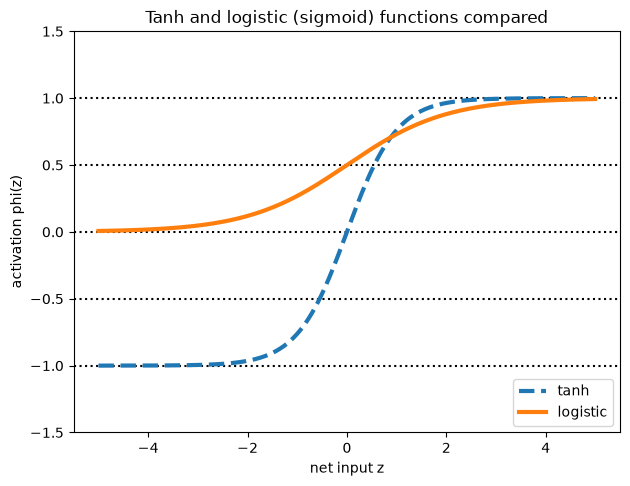

In [7]:
z = np.arange(-5.0, 5.0, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
this_title = "Tanh and logistic (sigmoid) functions compared"

plt.ylim([-1.5,1.5])
plt.xlabel('net input z')
plt.ylabel('activation phi(z)')
plt.axhline(1, color = 'black', linestyle = ':')
plt.axhline(0.5, color = 'black', linestyle = ':')
plt.axhline(0, color = 'black', linestyle = ':')
plt.axhline(-0.5, color = 'black', linestyle = ':')
plt.axhline(-1.0, color = 'black', linestyle = ':')
plt.plot(z, tanh_act, linewidth=3, linestyle='--', label='tanh')
plt.plot(z, log_act, linewidth=3, label='logistic')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.title(this_title)
plt.show()


# tanh and logistic from torch

In [8]:
z = np.arange(-5.0, 5.0, 0.005)

tanh_z = torch.tanh(torch.tensor(z))
sig_z = torch.sigmoid(torch.tensor(z))

## ReLU : Rectified Linear Unit
### $\sigma(z) = max(0,z)$

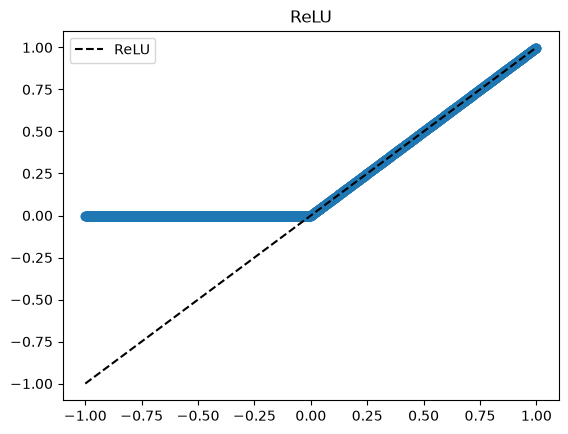

In [9]:
z = np.arange(-1.0, 1.0, 0.001)
relu_z_t = torch.relu(torch.tensor(z))
relu_z_np = np.asarray(relu_z_t.detach())

this_title = "ReLU"
plt.plot(z, z, color = 'black', linestyle='--', label = "ReLU")
plt.scatter(z, relu_z_np)
plt.title(this_title)
plt.legend()
plt.show()

## GeLU : Gaussian-error Linear Unit 
### $\sigma(x) = x \Phi(x)$, where $\Phi(x) = {\mathbb{P}}(X \le x)$ is the cumulative distribution function of the standard normal distribution

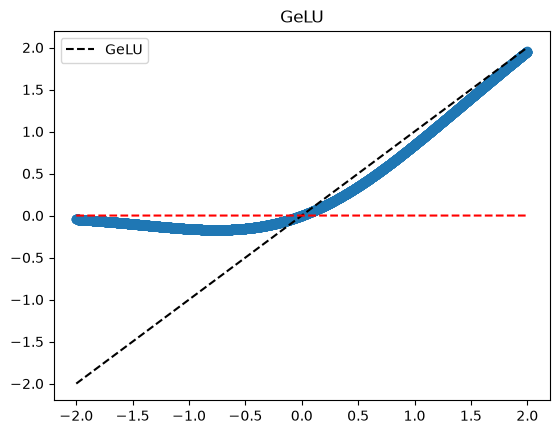

In [10]:
# Create a GELU activation layer
gelu = nn.GELU()

z = np.arange(-2.0, 2.0, 0.001)
gelu_z_t = gelu(torch.tensor(z))
gelu_z_np = np.asarray(gelu_z_t.detach())

this_title = "GeLU"
plt.plot(z, z, color = 'black', linestyle='--', label = "GeLU")
plt.plot(z, np.zeros(len(z)), color = 'red', linestyle='--')
plt.scatter(z, gelu_z_np)
plt.legend()
plt.title(this_title)
plt.show()

# ELU : Exponential Linear Unit 
### $f(x) =  \left\{
\begin{aligned}
x \, : \, x \geq 0 \\
\alpha (e^x - 1) \, : \, x \leq 0
\end{aligned}
\right.$
where $\alpha$ is a hyperparameter satisfying $\alpha > 0$.
Continuity of $f'(x)$ at $x=0$ requires $\alpha = 1.0$

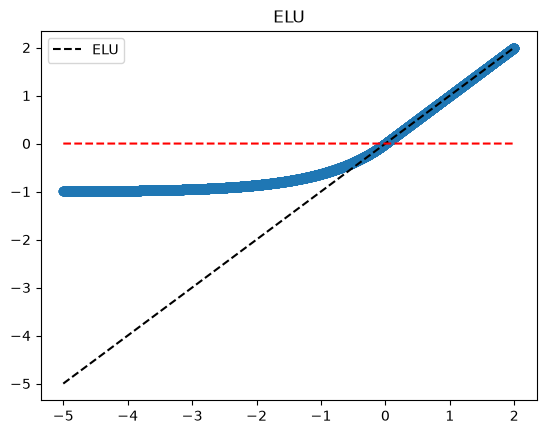

In [11]:
# Default ELU (alpha=1.0, inplace=False)
elu = nn.ELU()

z = np.arange(-5.0, 2.0, 0.001)
elu_z_t = elu(torch.tensor(z))
elu_z_np = np.asarray(elu_z_t.detach())

this_title = "ELU"
plt.plot(z, z, color = 'black', linestyle='--', label = "ELU")
plt.plot(z, np.zeros(len(z)), color = 'red', linestyle='--')
plt.scatter(z, elu_z_np)
plt.legend()
plt.title(this_title)
plt.show()